# DCGAN con CelebA (Versión Corregida)
Notebook corregido para entrenamiento estable de DCGAN.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import os

In [2]:
IMG_SIZE = 64
NC = 3
NZ = 100
NGF = 64
NDF = 64
BATCH_SIZE = 64
EPOCHS = 50
LR = 0.0002
BETA1 = 0.5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Dataset (CelebA)

In [4]:
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

dataset = datasets.ImageFolder(root='./archive (4)/img_align_celeba', transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [5]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.inp = nn.Sequential(
            nn.Linear(NZ, NGF*8*4*4, bias=False),
            nn.BatchNorm1d(NGF*8*4*4)
        )
        self.main = nn.Sequential(
            nn.ConvTranspose2d(NGF*8, NGF*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(NGF*4, NGF*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(NGF*2, NGF, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF),
            nn.ReLU(True),

            nn.ConvTranspose2d(NGF, NC, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.inp(z)
        x = x.view(-1, NGF*8, 4, 4)
        return self.main(x)

In [10]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(NC, NDF, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2),

            nn.Conv2d(NDF, NDF*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF*2),
            nn.LeakyReLU(0.2),

            nn.Conv2d(NDF*2, NDF*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF*4),
            nn.LeakyReLU(0.2),

            nn.Conv2d(NDF*4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x).view(x.size(0), -1).mean(dim=1, keepdim=True)

In [11]:
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = optim.Adam(G.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=LR, betas=(BETA1, 0.999))

## Entrenamiento corregido

Epoch 0 | Loss D: 1.2612 | Loss G: 1.4315


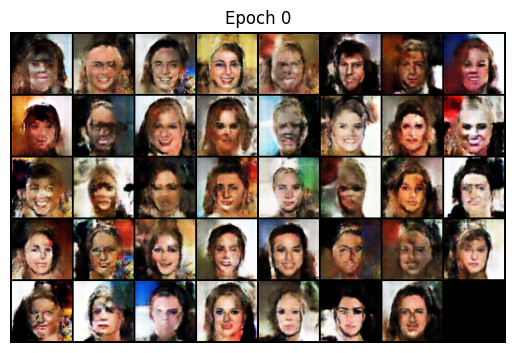

Epoch 1 | Loss D: 0.3806 | Loss G: 2.1442


KeyboardInterrupt: 

In [12]:
for epoch in range(EPOCHS):
    for real, _ in dataloader:

        real = real.to(device)
        batch_size = real.size(0)

        real_labels = torch.ones(batch_size,1).to(device)
        fake_labels = torch.zeros(batch_size,1).to(device)

        # Discriminador
        optimizer_D.zero_grad()

        output_real = D(real)
        loss_real = criterion(output_real, real_labels)

        noise = torch.randn(batch_size, NZ).to(device)
        fake = G(noise)

        output_fake = D(fake.detach())
        loss_fake = criterion(output_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        # Generador
        optimizer_G.zero_grad()

        output_fake = D(fake)
        loss_G = criterion(output_fake, real_labels)

        loss_G.backward()
        optimizer_G.step()

    print(f"Epoch {epoch} | Loss D: {loss_D.item():.4f} | Loss G: {loss_G.item():.4f}")

    if epoch % 5 == 0:
        grid = vutils.make_grid(fake, normalize=True)
        plt.imshow(grid.permute(1,2,0).cpu().detach().numpy())
        plt.title(f"Epoch {epoch}")
        plt.axis('off')
        plt.show()